# SIFT - Harris
### SIFT - Harris


maximum_filter:
https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.maximum_filter.html
gaussian_filter:https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.filters.gaussian_filter.html
sobel:https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.sobel.html

matplotlib.patches: https://matplotlib.org/api/patches_api.html

np.where: https://docs.scipy.org/doc/numpy-1.15.1/reference/generated/numpy.where.html
np.argwhere: https://docs.scipy.org/doc/numpy-1.15.1/reference/generated/numpy.argwhere.html

In [1]:
from commonfunctions import *
%matplotlib inline
%load_ext autoreload
%autoreload 2

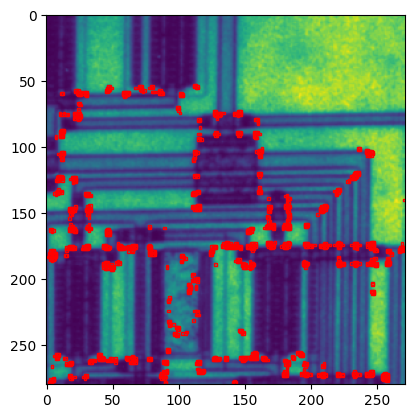

In [ ]:
from skimage.filters import gaussian
from scipy.ndimage import maximum_filter,gaussian_filter,sobel
import matplotlib.patches as patches

eps=1e-6
img = io.imread('circuit.tif') / 255

# TODO perform gaussian_filter, this will make the image less noisy not a step in the Harris algorithm

img = gaussian_filter(img, sigma=0.5)

# TODO perform sobel to get x-change and y-change

Ix = sobel_h(img)
Iy = sobel_v(img)

# In the following 3 TODOs, we are using a guassian as our window function. 
# We could have just used an averaging filter.
# TODO perform gaussian_filter on x-change * x-change to get sum of Ixx (i.e Sx2)
# TODO perform gaussian_filter on x-change * y-change to get sum of Ixy (i.e Sxy)
# TODO perform gaussian_filter on y-change * y-change to get sum of Iyy (i.e Sy2)

Ixx = Ix * Ix
Ixy = Ix * Iy
Iyy = Iy * Iy

Sx_2 = gaussian_filter(Ixx, sigma=1)
Sxy = gaussian_filter(Ixy, sigma=1)
Sy_2 = gaussian_filter(Iyy, sigma=1) 

# TODO Get R value using the supplied equations (use **2 for power 2)
# TODO Get the R values which are local maximum and above a given threshold. 
# The maximum_filter will help you get the max value in a neighborhood.

R = (Sx_2 * Sy_2 - Sxy ** 2) / (Sx_2 + Sy_2 + eps)

T = 0.3 * R.max()
z = (R > T)


# From here we will assume that z is a binary mask where 1 means there is a corner
# This part will get the indices of z where z = true, then we will draw a small rectangle around those indices
indx = np.argwhere(z==True)

fig,ax = plt.subplots(1)
ax.imshow(img)

for ind in indx:
    rect = patches.Rectangle((ind[1],ind[0]),2,2,linewidth=1,edgecolor='r',facecolor='none')
    ax.add_patch(rect)
plt.show()

[ WARN:0@0.016] global shadow_sift.hpp:13 SIFT_create DEPRECATED: cv.xfeatures2d.SIFT_create() is deprecated due SIFT tranfer to the main repository. https://github.com/opencv/opencv/issues/16736


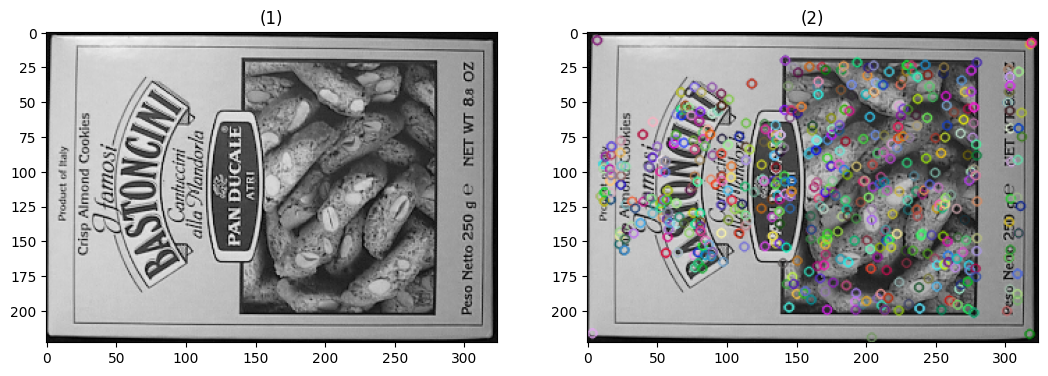

In [3]:
import numpy as np
import cv2
from matplotlib import pyplot as plt


sift = cv2.xfeatures2d.SIFT_create()

## TODO: read image box.png and box_in_scene

boxImg = io.imread('./box.png')
box_in_sceneImg = io.imread('./box_in_scene.png')


## TODO: find the keypoints and descriptors with SIFT
# Use sift.detectAndCompute

keypoints1, descriptors1 = sift.detectAndCompute(boxImg, mask=None)
keypoints2, descriptors2 = sift.detectAndCompute(box_in_sceneImg, mask=None)

#This function returns the main keypoints or interest points in the image and also the descriptors that have the features of the image


#Draw keypoints of img1 using cv2.drawKeypoints

outputBoxImg = np.copy(boxImg)
outputBoxImg = cv2.drawKeypoints(boxImg, keypoints1, outputBoxImg)

show_images([boxImg , outputBoxImg])

#This image shows the key points of the original image

## TODO: Construct BFMatcher, Hint use cv2.BFMatcher
## Use knnMatch with k = 2 to get the matches between the descriptors 


## TODO: Apply ratio test to remove ambigiuous matched (points that has multiple matches)
## Hint: use the distance in match 
## For k=2 knnMatch return the 2 closest matches anyways.
## if the distance between the keypoints and its 2 neighbours is close, then the keypoint is ambigious and 
## you should neglect it



## TODO: Draw the matches features use cv2.drawMatchesKnn with flags =4 



# plt.imshow(img3),plt.show()

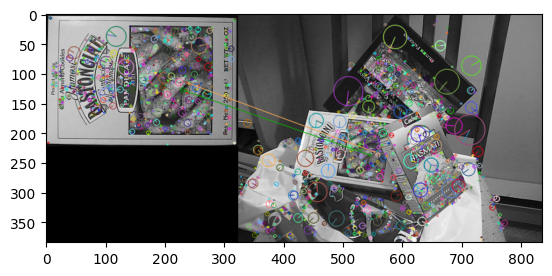

In [4]:
bf = cv2.BFMatcher()
matches = bf.knnMatch(descriptors1, descriptors2, k=2)

goodMatches = []

for m, n in matches :
    if m.distance < 0.232 * n.distance:
        goodMatches.append([m])

matched_features = cv2.drawMatchesKnn(boxImg, keypoints1, box_in_sceneImg, keypoints2, goodMatches, None, flags=4)

#Matching steps:
# knnMatch returns every possible match between 2 images using their sift descriptors and then by using certain distance as a threshold we can get the best matches

# We can use any other feature extractor like hog to get features from some images and then using them to get the similarity among the images

#The picture having many books tries to match one book among them to another picture focusing on the same book

plt.imshow(matched_features)
plt.show()